In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pricing_engine.data_access.pricing_data import PricingData
from pricing_engine.logger import logging

%matplotlib inline

In [12]:
try:
    pricing_data = PricingData()
    df = pricing_data.export_collection_as_dataframe(collection_name="product_features")
    print(f"Dataset shape: {df.shape}")
except Exception as e:
    print(f"Error: {e}")

Dataset shape: (150838, 40)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150838 entries, 0 to 150837
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       150838 non-null  object 
 1   order_item_id                  150838 non-null  int64  
 2   product_id                     150838 non-null  object 
 3   seller_id                      150838 non-null  object 
 4   shipping_limit_date            150838 non-null  object 
 5   price                          150838 non-null  float64
 6   freight_value                  150838 non-null  float64
 7   customer_id                    150838 non-null  object 
 8   order_status                   150838 non-null  object 
 9   order_purchase_timestamp       150838 non-null  object 
 10  order_approved_at              150819 non-null  object 
 11  order_delivered_carrier_date   149210 non-null  object 
 12  order_delivered_customer_date 

In [14]:
df.describe()


,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_zip_code_prefix,seller_zip_code_prefix,review_score,payment_sequential,payment_installments,payment_value
count,150838.000000,150838.000000,150838.000000,148654.000000,148654.000000,148654.000000,150814.000000,150814.000000,150814.000000,150814.000000,150838.000000,150838.000000,149606.000000,150835.000000,150835.000000,150835.000000
mean,1.197059,120.555662,20.043823,48.753629,785.968134,2.200896,2102.779450,30.233539,16.594235,23.056812,35063.547276,24458.051260,4.031590,1.093261,2.941784,173.140947
std,0.701752,184.502697,15.882679,10.044418,653.155976,1.713141,3772.975377,16.166814,13.437932,11.760211,29829.939408,27587.120442,1.387181,0.710157,2.774558,280.983973
min,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1003.000000,1001.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,39.900000,13.070000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,11310.000000,6429.000000,4.000000,1.000000,1.000000,60.960000
50%,1.000000,74.900000,16.290000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,24241.000000,13660.000000,5.000000,1.000000,2.000000,108.200000
75%,1.000000,134.570000,21.190000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,58701.000000,28605.000000,5.000000,1.000000,4.000000,189.000000
max,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99990.000000,99730.000000,5.000000,29.000000,24.000000,13664.080000


In [15]:
# Check for missing values
df.isnull().sum()

order_id                              0
order_item_id                         0
product_id                            0
seller_id                             0
shipping_limit_date                   0
price                                 0
freight_value                         0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    19
order_delivered_carrier_date       1628
order_delivered_customer_date      3321
order_estimated_delivery_date         0
product_category_name              2184
product_name_lenght                2184
product_description_lenght         2184
product_photos_qty                 2184
product_weight_g                     24
product_length_cm                    24
product_height_cm                    24
product_width_cm                     24
product_category_name_english         0
customer_unique_id                    0
customer_zip_code_prefix              0


<Axes: xlabel='price', ylabel='Count'>

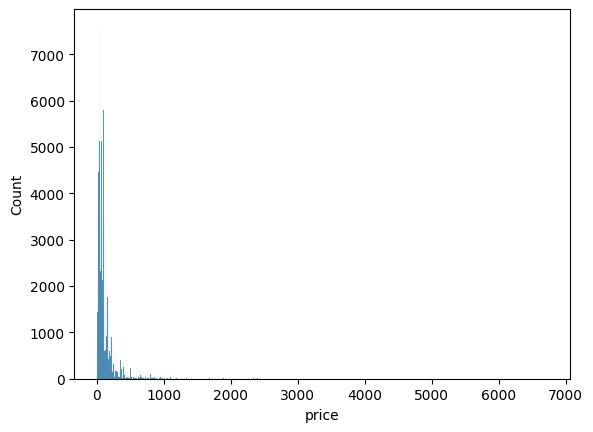

In [16]:
sns.histplot(df['price'])

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

def perform_feature_engineering(df):
    df = df.copy()
    
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
    df['purchase_month'] = df['order_purchase_timestamp'].dt.month
    df['purchase_day_of_week'] = df['order_purchase_timestamp'].dt.dayofweek
    df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour
    df['is_weekend'] = df['purchase_day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
    
    category_avg_price = df.groupby('product_category_name_english')['price'].transform('mean')
    df['category_price_ratio'] = df['price'] / category_avg_price
    
    df['freight_ratio'] = df['freight_value'] / df['price']
    
    df['product_volume_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']
    
    df['price_per_weight'] = df['price'] / (df['product_weight_g'] + 1)
    
    df['review_score'] = df['review_score'].fillna(df['review_score'].median())
    
    categorical_cols = ['product_category_name_english', 'payment_type', 'customer_state', 'seller_state']
    for col in categorical_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
    
    df['target_price_log'] = np.log1p(df['price'])
    
    cols_to_drop = ['order_id', 'product_id', 'seller_id', 'customer_id', 'order_status', 
                    'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 
                    'order_delivered_customer_date', 'order_estimated_delivery_date', 
                    'shipping_limit_date', 'review_id', 'review_comment_title', 
                    'review_comment_message', 'review_creation_date', 'review_answer_timestamp',
                    'product_category_name', 'customer_unique_id']
    
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    
    return df

df_final = perform_feature_engineering(df)
print(df_final.head())

   order_item_id   price  freight_value  product_name_lenght  \
0              1   58.90          13.29                 58.0   
1              1  239.90          19.93                 56.0   
2              1  199.00          17.87                 59.0   
3              1   12.99          12.79                 42.0   
4              1  199.90          18.14                 59.0   

   product_description_lenght  product_photos_qty  product_weight_g  \
0                       598.0                 4.0             650.0   
1                       239.0                 2.0           30000.0   
2                       695.0                 2.0            3050.0   
3                       480.0                 1.0             200.0   
4                       409.0                 1.0            3750.0   

   product_length_cm  product_height_cm  product_width_cm  ...  payment_value  \
0               28.0                9.0              14.0  ...          72.19   
1               50.0      

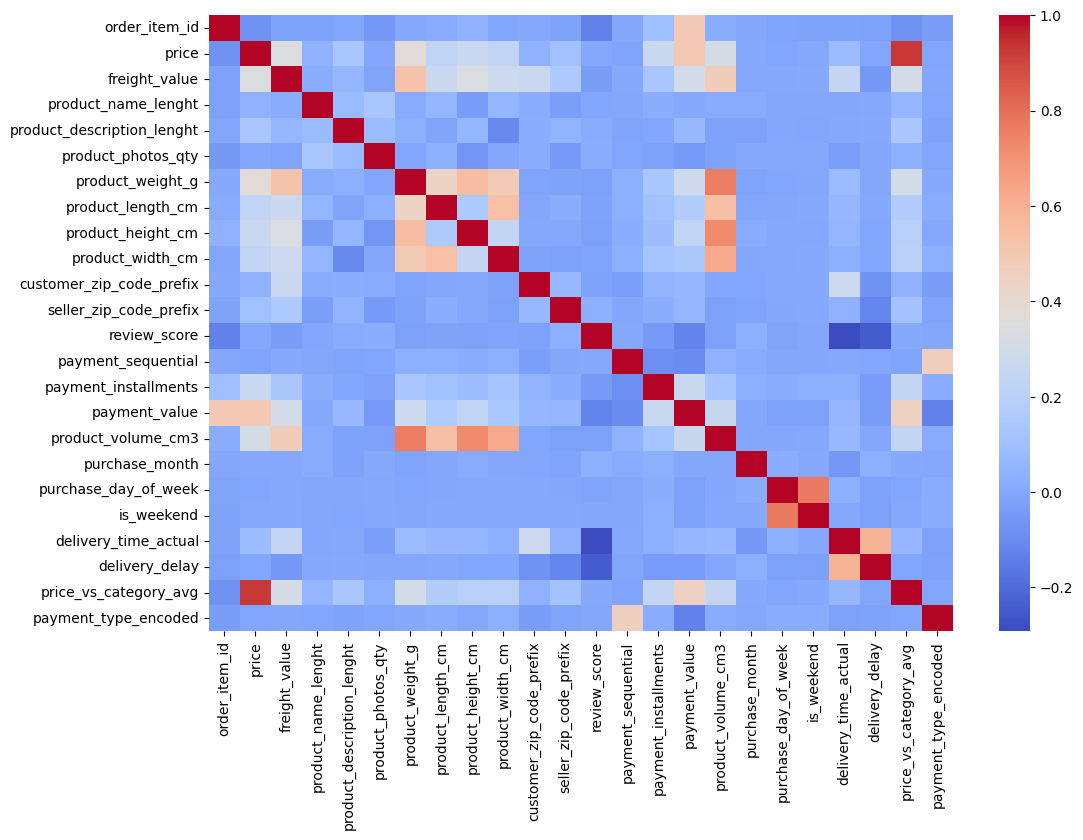

In [4]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

file_path = os.path.join('..', 'notebook', 'final_pricing_dataset_with_reviews.csv')
df = pd.read_csv(file_path)

date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df['review_score'] = df['review_score'].fillna(df['review_score'].mode()[0])
df['product_weight_g'] = df['product_weight_g'].fillna(df['product_weight_g'].median())

q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
df = df[df['price'] <= upper_limit]

df['product_volume_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']
df['product_volume_cm3'] = df['product_volume_cm3'].fillna(df['product_volume_cm3'].median())

df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_day_of_week'] = df['order_purchase_timestamp'].dt.dayofweek
df['is_weekend'] = df['purchase_day_of_week'].isin([5, 6]).astype(int)

df['delivery_time_actual'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delivery_delay'] = df['delivery_time_actual'] - ((df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days)
df['delivery_delay'] = df['delivery_delay'].fillna(0)

category_avg = df.groupby('product_category_name_english')['price'].transform('mean')
df['price_vs_category_avg'] = df['price'] / (category_avg + 0.001)

le = LabelEncoder()
df['payment_type_encoded'] = le.fit_transform(df['payment_type'].astype(str))

cols_to_drop = ['review_comment_title', 'review_comment_message', 'order_delivered_carrier_date']
df = df.drop(columns=cols_to_drop)

df.to_csv('final_engineered_data.csv', index=False)

plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.savefig('correlation_heatmap.png')

In [7]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder

file_path = os.path.join('..', 'notebook', 'final_pricing_dataset_with_reviews.csv')
df = pd.read_csv(file_path)

date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_approved_at']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
df = df[df['price'] <= upper_limit].copy()

fill_median = [
    'product_weight_g', 'product_length_cm', 'product_height_cm', 
    'product_width_cm', 'product_name_lenght', 'product_description_lenght', 
    'product_photos_qty', 'payment_sequential', 'payment_installments', 'payment_value'
]
for col in fill_median:
    df[col] = df[col].fillna(df[col].median())

df['review_score'] = df['review_score'].fillna(df['review_score'].mode()[0])

df['product_volume_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']

df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_day_of_week'] = df['order_purchase_timestamp'].dt.dayofweek
df['is_weekend'] = df['purchase_day_of_week'].isin([5, 6]).astype(int)

df['delivery_time_actual'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delivery_time_estimated'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['delivery_delay'] = df['delivery_time_actual'] - df['delivery_time_estimated']

df['delivery_time_actual'] = df['delivery_time_actual'].fillna(df['delivery_time_actual'].median())
df['delivery_delay'] = df['delivery_delay'].fillna(df['delivery_delay'].median())

category_avg = df.groupby('product_category_name_english')['price'].transform('mean')
df['price_vs_category_avg'] = df['price'] / (category_avg + 0.0001)
df['price_vs_category_avg'] = df['price_vs_category_avg'].fillna(1.0)

le = LabelEncoder()
categorical_cols = ['order_status', 'product_category_name_english', 'customer_state', 'seller_state', 'payment_type']
for col in categorical_cols:
    df[col] = df[col].fillna('unknown')
    df[col] = le.fit_transform(df[col].astype(str))

cols_to_drop = [
    'order_id', 'product_id', 'seller_id', 'customer_id', 'customer_unique_id', 
    'review_id', 'shipping_limit_date', 'order_purchase_timestamp', 
    'order_approved_at', 'order_delivered_carrier_date', 
    'order_delivered_customer_date', 'order_estimated_delivery_date',
    'review_comment_title', 'review_comment_message', 'review_creation_date', 
    'review_answer_timestamp', 'product_category_name', 'customer_city', 'seller_city'
]
df = df.drop(columns=cols_to_drop)

output_path = os.path.join('..', 'notebook', 'final_engineered_data.csv')
df.to_csv(output_path, index=False)

In [8]:
import pandas as pd
import numpy as np
import os

file_path = os.path.join('..', 'notebook', 'final_engineered_data.csv')
df = pd.read_csv(file_path)

print("--- Test 1: Null Value Check ---")
null_counts = df.isnull().sum().sum()
if null_counts == 0:
    print("✅ Success: No Null values found!")
else:
    print(f"❌ Failed: {null_counts} null values still exist.")

print("\n--- Test 2: Numerical Format Check ---")
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
if len(non_numeric_cols) == 0:
    print("✅ Success: All columns are numerical!")
else:
    print(f"⚠️ Warning: These columns are not numerical yet: {non_numeric_cols}")

print("\n--- Test 3: Feature Correlation with Price ---")
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['price'].sort_values(ascending=False)

print("Top Correlations with Price:")
print(correlations.head(10))

strong_features = correlations[abs(correlations) > 0.1].index.tolist()
print(f"\n💡 Summary: {len(strong_features)} features have a strong correlation (>0.1) with price.")

--- Test 1: Null Value Check ---
✅ Success: No Null values found!

--- Test 2: Numerical Format Check ---
✅ Success: All columns are numerical!

--- Test 3: Feature Correlation with Price ---
Top Correlations with Price:
price                    1.000000
price_vs_category_avg    0.925002
payment_value            0.496957
product_weight_g         0.375611
freight_value            0.340608
product_volume_cm3       0.316901
payment_installments     0.265671
product_height_cm        0.258571
product_width_cm         0.231271
product_length_cm        0.223668
Name: price, dtype: float64

💡 Summary: 13 features have a strong correlation (>0.1) with price.
